<H2 style="text-align:center;"><strong>VARIABLES ONLINE</strong></H2>

**Objetivo General:**
Diseñar un modelo predictivo basado en técnicas de aprendizaje automático que, utilizando únicamente variables online disponibles en el proceso de fermentación, permita estimar la concentración de penicilina en tiempo real.

**Objetivos específicos:**
1. Identificar y seleccionar variables online relevantes del dataset IndPenSim que incidan en la producción de penicilina.
2. Estandarizar, limpiar y preparar los datos para su uso en modelos de predicción.
3. Entrenar y evaluar distintos modelos de regresión (Lasso, SVR, KNN, ANN, XGBoost) para estimar la concentración del producto.
4. Validar el desempeño de los modelos mediante métricas como el error cuadrático medio (RMSE), error absoluto medio (MAE) y coeficiente de determinación (R²).
5. Integrar un modelo final en un esquema de sensor blando (soft sensor), que simule su uso en una planta industrial.



## Importar Librerias

In [54]:
# Manejo de datos
import pandas as pd
import numpy as np
# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
# Isolation Forest
from sklearn.ensemble import IsolationForest



# Ignorar advertencias (opcional, para limpieza visual)
import warnings
warnings.filterwarnings('ignore')

## Cargar y visualizar datos

En este paso cargamos los datos utilizando un directorio

In [6]:
data = pd.read_csv(r'C:/Users/Sandra Orozco\Dropbox/Maestria IAA/Reto Icesi INRAE/Mendeley_data/100_Batches_IndPenSim_V3.csv')
data

,Time (h),Aeration rate(Fg:L/h),Agitator RPM(RPM:RPM),Sugar feed rate(Fs:L/h),Acid flow rate(Fa:L/h),Base flow rate(Fb:L/h),Heating/cooling water flow rate(Fc:L/h),Heating water flow rate(Fh:L/h),Water for injection/dilution(Fw:L/h),Air head pressure(pressure:bar),...,210,209,208,207,206,205,204,203,202,201
0,0.2,30,100,8,0.0000,30.1180,9.8335,0.00010,0,0.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
1,0.4,30,100,8,0.0000,51.2210,18.1550,0.00010,0,0.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2,0.6,30,100,8,0.0000,54.3020,9.5982,0.00010,0,0.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
3,0.8,30,100,8,0.0000,37.8160,4.3395,0.00010,0,0.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
4,1.0,30,100,8,0.5181,18.9080,1.1045,0.00010,0,0.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113930,229.2,65,100,80,0.0000,12.9000,33.5860,5.93590,250,0.9,...,816050.0,823390.0,830160.0,835530.0,839140.0,840570.0,840160.0,838580.0,NaN,NaN
113931,229.4,65,100,80,0.0000,10.0470,10.0760,98.83400,250,0.9,...,773520.0,780840.0,787470.0,792750.0,796220.0,797610.0,797270.0,796020.0,NaN,NaN
113932,229.6,65,100,80,0.0000,7.3609,69.3450,9.88340,250,0.9,...,788240.0,795550.0,802190.0,807420.0,810590.0,811660.0,811210.0,809960.0,NaN,NaN
113933,229.8,65,100,80,0.0000,6.2794,38.6100,0.98834,250,0.9,...,781180.0,788420.0,794950.0,800140.0,803610.0,804900.0,804490.0,803410.0,NaN,NaN


Aquí evidenciamos los tipos de variables que exiten en dataset y la forma general de los datos. En este caso encontramos variables float e int, así mismo observamos que hay columnas con valores nulos.

In [7]:
print("\nInformación del dataset:")
data.info()

print("\nForma general de los datos:")
display(data.describe().T)


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113935 entries, 0 to 113934
Columns: 2239 entries, Time (h) to 201
dtypes: float64(2225), int64(14)
memory usage: 1.9 GB

Forma general de los datos:


,count,mean,std,min,25%,50%,75%,max
Time (h),113935.0,1.147507e+02,66.990504,0.2,57.0,114.0,171.0,290.000
Aeration rate(Fg:L/h),113935.0,6.524636e+01,11.690215,20.0,60.0,65.0,75.0,75.000
Agitator RPM(RPM:RPM),113935.0,1.000000e+02,0.000000,100.0,100.0,100.0,100.0,100.000
Sugar feed rate(Fs:L/h),113935.0,7.666376e+01,25.680134,2.0,72.0,80.0,90.0,150.000
Acid flow rate(Fa:L/h),113935.0,7.320937e-02,0.552788,0.0,0.0,0.0,0.0,12.996
...,...,...,...,...,...,...,...,...
205,113935.0,1.441100e+06,659721.197945,0.0,862085.0,1448400.0,1994100.0,2936400.000
204,113935.0,1.441329e+06,660341.546970,0.0,861785.0,1448600.0,1994900.0,2938300.000
203,113935.0,1.440539e+06,660944.062181,0.0,860445.0,1447800.0,1994600.0,2939400.000
202,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Se genera un archivo .txt para conocer y explorar todas las columnas del dataset

In [8]:
with open('columnas.txt', 'w') as file:
    for col in data.columns:
        file.write(col + '\n')

Identificamos los valores nulos por cada columna

In [12]:
print("\nValores nulos en cada columna:")
print(data.isnull().sum())  


Valores nulos en cada columna:
Time (h)                        0
Aeration rate(Fg:L/h)           0
Agitator RPM(RPM:RPM)           0
Sugar feed rate(Fs:L/h)         0
Acid flow rate(Fa:L/h)          0
                            ...  
205                             0
204                             0
203                             0
202                        113935
201                        113935
Length: 2239, dtype: int64


### Análisis de Correlación 

Para hacer un Análisis de Correlación primero debemos filtrar las variables de proceso (variables online) y excluir los espectros Raman.

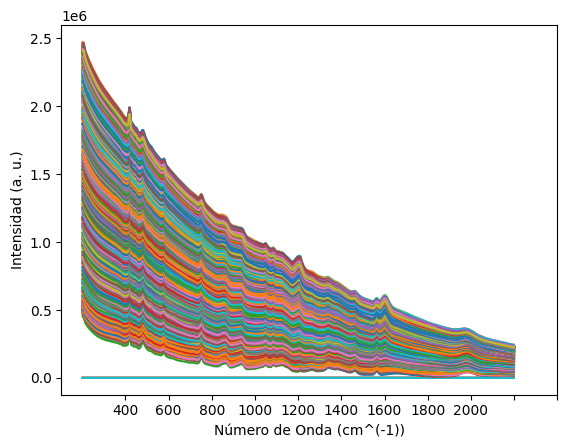

In [15]:
variable_raman_data = np.split(data, [data.columns.get_loc("2400")], axis=1) # dividimos nuestros datos en variables y espectros. 
variable_data = variable_raman_data[0] # asignación a la variable los datos anteriores a 2400 (columna 0 a la 39)

# Se encontró que hay dos columnas con nombres cruzados por lo tanto se intercambian nombres de las columnas
variable_data = variable_data.rename(columns={'2-PAT control(PAT_ref:PAT ref)': 'Batch reference(Batch_ref:Batch ref)','Batch reference(Batch_ref:Batch ref)':'2-PAT control(PAT_ref:PAT ref)'})

raman_spectra = variable_raman_data[1] # Separación de los espectros

# Gráfica espectros Raman

Intensity = raman_spectra.iloc[0:1129, 201:2600]
Temp = Intensity.transpose()

Temp_inverted = Temp.iloc[::-1]

Temp_inverted.index

x_values = np.array(Temp_inverted.index)

for column in Temp:
    # Convertir la serie de Pandas a un array de NumPy
    y_values = np.array(Temp_inverted[column])

    plt.plot(x_values, y_values, label=column)

x_ticks = range(199, 2399, 200)
plt.xticks(x_ticks) 
plt.ylabel('Intensidad (a. u.)')
plt.xlabel('Número de Onda (cm^(-1))')

plt.show()

In [18]:
# variables disponibles
variables = variable_data.columns.tolist()  
print("\nVariables disponibles en el dataset:")
for var in variables:
    print(var)
# Guardar las variables disponibles en un archivo de texto
with open('variables_disponibles.txt', 'w') as file:
    for var in variables:
        file.write(var + '\n')


Variables disponibles en el dataset:
Time (h)
Aeration rate(Fg:L/h)
Agitator RPM(RPM:RPM)
Sugar feed rate(Fs:L/h)
Acid flow rate(Fa:L/h)
Base flow rate(Fb:L/h)
Heating/cooling water flow rate(Fc:L/h)
Heating water flow rate(Fh:L/h)
Water for injection/dilution(Fw:L/h)
Air head pressure(pressure:bar)
Dumped broth flow(Fremoved:L/h)
Substrate concentration(S:g/L)
Dissolved oxygen concentration(DO2:mg/L)
Penicillin concentration(P:g/L)
Vessel Volume(V:L)
Vessel Weight(Wt:Kg)
pH(pH:pH)
Temperature(T:K)
Generated heat(Q:kJ)
carbon dioxide percent in off-gas(CO2outgas:%)
PAA flow(Fpaa:PAA flow (L/h))
PAA concentration offline(PAA_offline:PAA (g L^{-1}))
Oil flow(Foil:L/hr)
NH_3 concentration off-line(NH3_offline:NH3 (g L^{-1}))
Oxygen Uptake Rate(OUR:(g min^{-1}))
Oxygen in percent in off-gas(O2:O2  (%))
Offline Penicillin concentration(P_offline:P(g L^{-1}))
Offline Biomass concentratio(X_offline:X(g L^{-1}))
Carbon evolution rate(CER:g/h)
Ammonia shots(NH3_shots:kgs)
Viscosity(Viscosity_o

### Selección de Variables 

Teniendo en cuenta que vamos a trabajar por lotes procedemos a especificar variables seleccionada. Se seleccionaron variables online por su disponibilidad en tiempo real, relevancia en la dinámica del proceso (como pH, temperatura, oxígeno, agitación) y correlación con la producción de penicilina. Además, `Time` y `Batch ID` permiten analizar la evolución del proceso por lote.


1.  Time (h)
2.  Agitator RPM(RPM:RPM)
3.  Sugar feed rate(Fs:L/h)
4.  Dissolved oxygen concentration(DO2:mg/L)
5.  Penicillin concentration(P:g/L) --> VARIABLE OBJETIVO
6.  Vessel Volume(V:L)
7.  pH(pH:pH)
8.  Temperature(T:K)
9.  Carbon dioxide percent in off-gas(CO2outgas:%)
10. Oxygen in percent in off-gas(O2:O2  (%))
11. Batch ID



In [22]:
data_select = data[['Time (h)', 'Agitator RPM(RPM:RPM)', 'Sugar feed rate(Fs:L/h)', 'Dissolved oxygen concentration(DO2:mg/L)', 
                    'Penicillin concentration(P:g/L)', 'Vessel Volume(V:L)', 'pH(pH:pH)', 'Temperature(T:K)', 'carbon dioxide percent in off-gas(CO2outgas:%)', 
                    'Oxygen in percent in off-gas(O2:O2  (%))', '2-PAT control(PAT_ref:PAT ref)']]                       
                    
# Renombramos la variable 2-PAT control(PAT_ref:PAT ref)': 'Batch'
data_select = data_select.rename(columns={'2-PAT control(PAT_ref:PAT ref)': 'Batch'})
data_select.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
Time (h),113935.0,114.750656,66.990504,2.000000e-01,57.00000,114.00000,171.00000,290.00000
Agitator RPM(RPM:RPM),113935.0,100.000000,0.000000,1.000000e+02,100.00000,100.00000,100.00000,100.00000
Sugar feed rate(Fs:L/h),113935.0,76.663764,25.680134,2.000000e+00,72.00000,80.00000,90.00000,150.00000
Dissolved oxygen concentration(DO2:mg/L),113935.0,12.569647,1.498680,1.000000e+00,11.63900,12.63600,13.61400,16.50800
Penicillin concentration(P:g/L),113935.0,14.333946,9.932453,3.694700e-26,5.53125,14.38000,22.68750,36.18300
Vessel Volume(V:L),113935.0,73312.865441,8599.642160,5.654900e+04,65885.50000,75770.00000,79892.00000,95716.00000
pH(pH:pH),113935.0,6.496565,0.065676,5.395700e+00,6.49320,6.50090,6.50860,6.76640
Temperature(T:K),113935.0,298.026489,0.197513,2.968400e+02,297.95000,297.99000,298.04000,302.18000
carbon dioxide percent in off-gas(CO2outgas:%),113935.0,1.444042,0.498955,7.542500e-02,1.22590,1.59630,1.75730,7.12140
Oxygen in percent in off-gas(O2:O2 (%)),113935.0,0.191458,0.004718,1.295000e-01,0.18886,0.19118,0.19366,0.22751


Identificamos los valores Nulos del Data seleccionado

In [30]:
# Calcular nulos por columna
valores_nulos = data_select.isnull().sum()

# Filtrar solo las columnas que tienen al menos un valor nulo
variables_con_nulos = valores_nulos[valores_nulos > 0]

# Mostrar resultados
print("Columnas con valores nulos:")
print(variables_con_nulos)

Columnas con valores nulos:
Series([], dtype: int64)


Definimos las Variables para el Análisis Exploratorio de Datos. Aqui no definimos: Time (h), Penicillin concentration(P:g/L)

In [32]:
variables = [
    'Agitator RPM(RPM:RPM)', 
    'Sugar feed rate(Fs:L/h)', 
    'Dissolved oxygen concentration(DO2:mg/L)', 
    'Vessel Volume(V:L)',
    'pH(pH:pH)',
    'Temperature(T:K)', 
    'carbon dioxide percent in off-gas(CO2outgas:%)', 
    'Oxygen in percent in off-gas(O2:O2  (%))'
]

Calculamos estadísticas descriptivas (media, mediana, desviación estándar, máximos y mínimos) para las variables clave del proceso. Además, se graficaron histogramas para observar la distribución de los datos y boxplots para identificar posibles valores atípicos.


In [37]:
# Filtrar datos relevantes
data_stats = data[variables]

# Calcular estadísticas descriptivas
estadisticas = data_stats.describe().T  # Transpuesta para mayor legibilidad
estadisticas['mediana'] = data_stats.median()
estadisticas = estadisticas[['mean', 'mediana', 'std', 'min', 'max']]

# Mostrar resumen
print("Estadísticas descriptivas:")
display(estadisticas)


Estadísticas descriptivas:


,mean,mediana,std,min,max
Agitator RPM(RPM:RPM),100.000000,100.00000,0.000000,100.000000,100.00000
Sugar feed rate(Fs:L/h),76.663764,80.00000,25.680134,2.000000,150.00000
Dissolved oxygen concentration(DO2:mg/L),12.569647,12.63600,1.498680,1.000000,16.50800
Vessel Volume(V:L),73312.865441,75770.00000,8599.642160,56549.000000,95716.00000
pH(pH:pH),6.496565,6.50090,0.065676,5.395700,6.76640
Temperature(T:K),298.026489,297.99000,0.197513,296.840000,302.18000
carbon dioxide percent in off-gas(CO2outgas:%),1.444042,1.59630,0.498955,0.075425,7.12140
Oxygen in percent in off-gas(O2:O2 (%)),0.191458,0.19118,0.004718,0.129500,0.22751


Visualizamos la distribucción a traves de Histogramas 

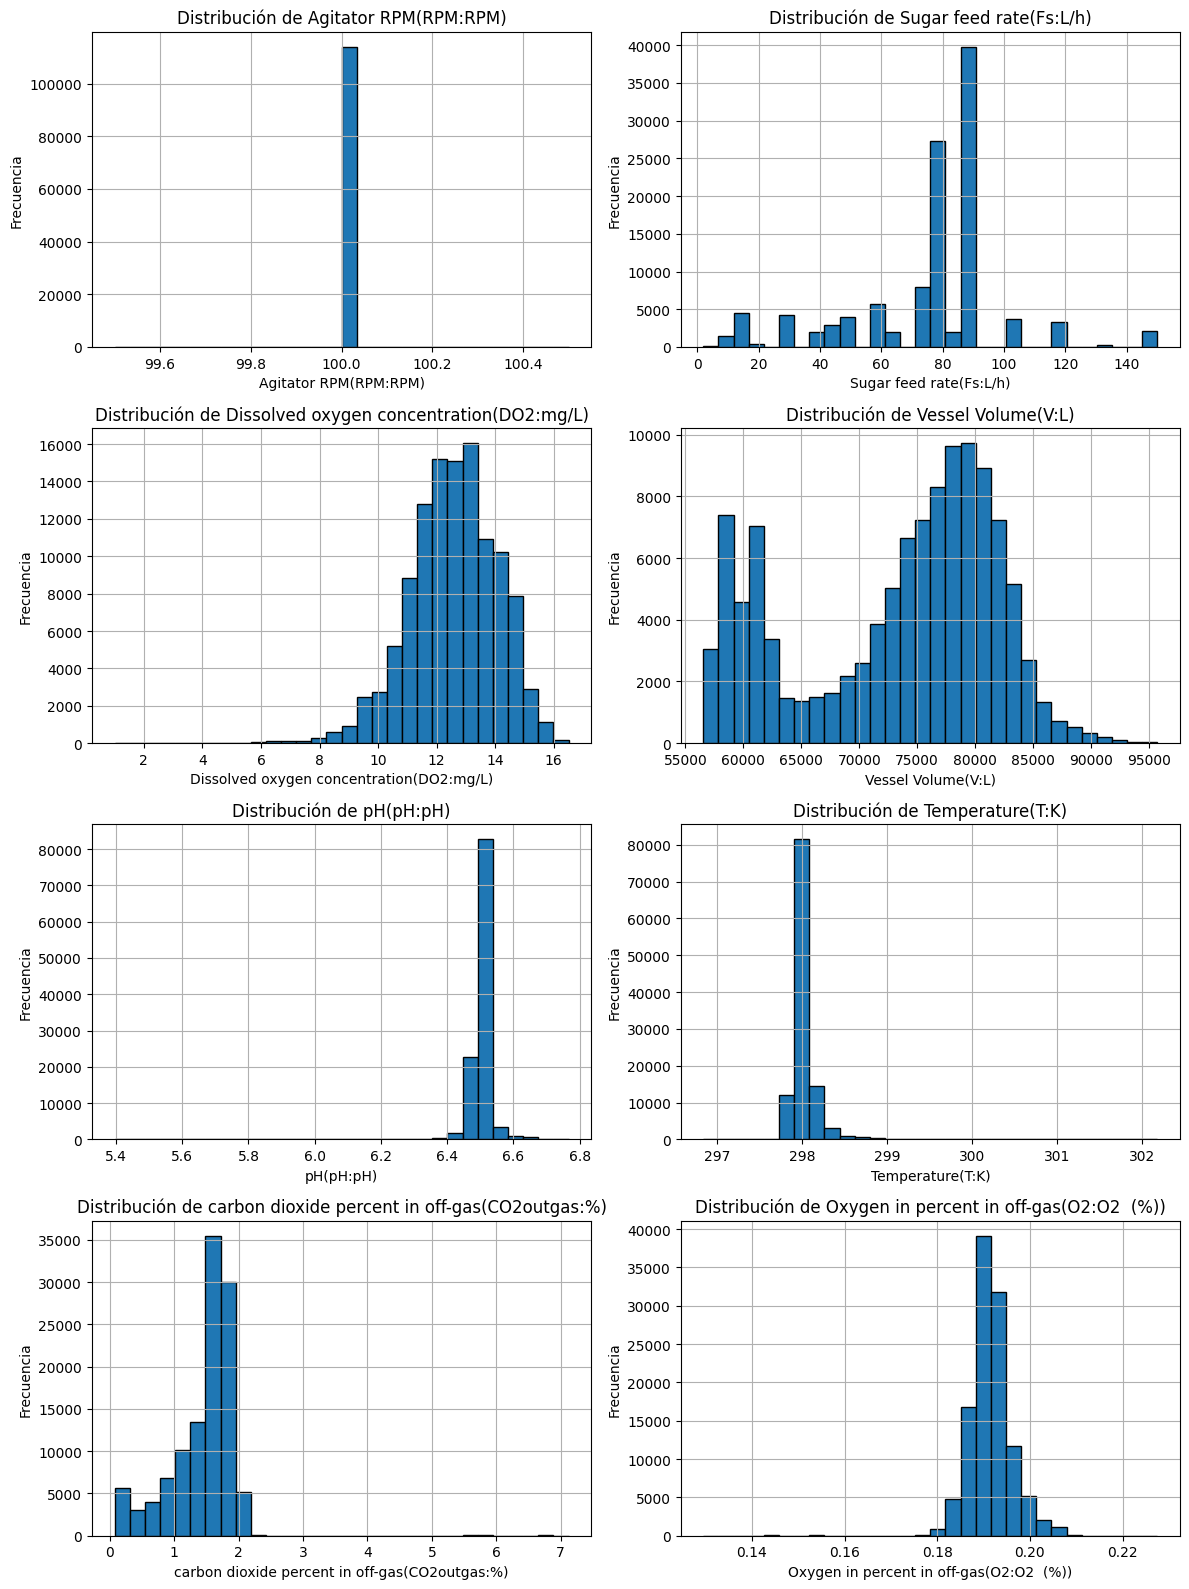

In [50]:
n = len(variables)
filas = (n + 1) // 2
fig, axes = plt.subplots(filas, 2, figsize=(12, 4 * filas))
axes = axes.flatten()
for i, var in enumerate(variables):
    data[var].hist(bins=30, edgecolor='black', ax=axes[i])
    axes[i].set_title(f"Distribución de {var}")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Frecuencia")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [57]:
print(data['Agitator RPM(RPM:RPM)'].unique())

[100]


In [56]:
# Crear el modelo
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)

# Entrenar el modelo
iso_forest.fit(variables)

# Predecir: -1 = outlier, 1 = normal
variables['outlier'] = iso_forest.predict(variables)

# Mostrar conteo
print("Distribución de etiquetas:")
print(variables['outlier'].value_counts())


ValueError: could not convert string to float: 'Agitator RPM(RPM:RPM)'

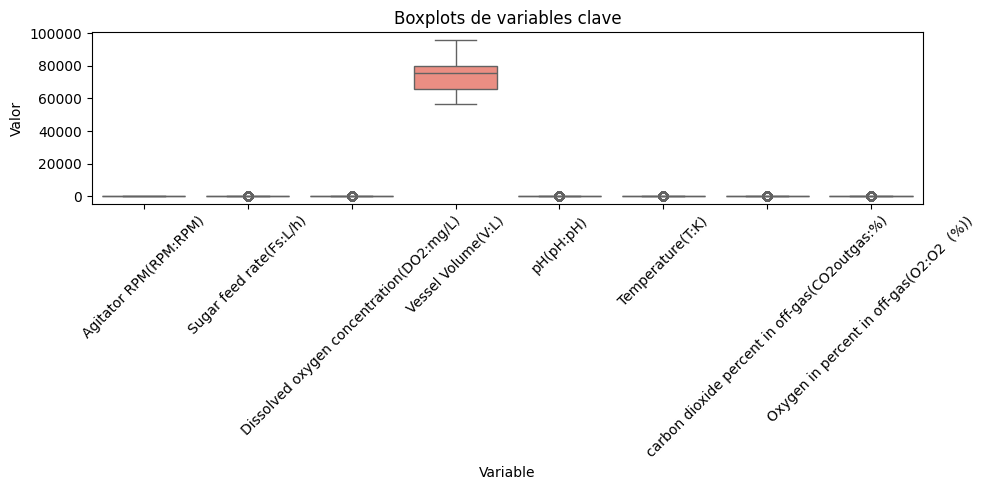

In [41]:
plt.figure(figsize=(10, 5))
data_melted = data[variables].melt()
sns.boxplot(x='variable', y='value', data=data_melted, palette='Set3')
plt.title("Boxplots de variables clave")
plt.xlabel("Variable")
plt.ylabel("Valor")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
